# Simulation 1 Context-Binding Figure

> Generate the focused Figure 2 workflow for the Simulation 1 context-binding mechanism.

This notebook keeps the interference-strength sweep as the behavioral output and adds model-internal diagnostics for temporal-context overlap and effective context-to-feature competition.
It is manuscript-facing rather than a broad diagnostic contact sheet.

In [1]:
import csv
import os
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random
from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root

from selective_interference_v2 import (
    PHASE_COLORS,
    Paradigm,
    add_phase_bands,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    make_is_target,
    prepare_sweep,
    run_sweep,
    save_figure,
    split_scales_for_cache,
    standard_remap,
)

warnings.filterwarnings("ignore")

In [2]:
# --- sweep configuration ---
PROJECT_ROOT = ""
FIT_PATH = "results/fits/Dupertuys2026_eCMR_source_only_phi_no_shared_support_best_of_1.json"
FIGURE_DIR = ""
FIGURE_STR = ""
RNG_SEED = 0

SWEEP_PARAM = "interference_mcf_scale"
SWEEP_VALUES = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
SWEEP_XLABEL = "Task learning factor"
SWEEP_LABEL_FMT = "{:.2f}"

N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
EXPERIMENT_COUNT = 5000
MAX_RECALL = 48

FILM_EMOTIONAL = False
INTERFERENCE_EMOTIONAL = False
CACHE_AFTER = "reminder"

BASE_FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

REMINDER_CONDITIONS = {
    "No reminder": {
        "reminder_start_drift_scale": 0.0,
        "reminder_drift_scale": 0.0,
    },
    "With reminder": {
        "reminder_start_drift_scale": 1.0,
        "reminder_drift_scale": 1.0,
    },
}

In [3]:
# Parameters
FIGURE_DIR = "figures"
FIGURE_STR = "simulation1_context_binding"


In [4]:
#| output: asis
if PROJECT_ROOT:
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(find_project_root())

fit_path = project_root / FIT_PATH
figure_dir = project_root / FIGURE_DIR if FIGURE_DIR else None
sweep_values = np.asarray(SWEEP_VALUES, dtype=float)

params, n_subjects = load_fit_params(fit_path)
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
    max_recall=MAX_RECALL,
)
factory = make_factory(
    is_emotional=make_is_emotional(
        paradigm,
        film_emotional=FILM_EMOTIONAL,
        interference_emotional=INTERFERENCE_EMOTIONAL,
    ),
    is_target=make_is_target(paradigm),
)
rng = random.PRNGKey(RNG_SEED)

Markdown(
    f"Loaded {n_subjects} fit parameter set(s). Running {len(sweep_values)} task-learning values "
    f"with {EXPERIMENT_COUNT} simulated trials per value."
)

Loaded 1 fit parameter set(s). Running 7 task-learning values with 5000 simulated trials per value.

In [5]:
def position_phase_labels(paradigm):
    return (
        ["film"] * paradigm.n_film
        + ["break"] * paradigm.n_break
        + ["task"] * paradigm.n_interference
        + ["filler"] * paradigm.n_filler
    )


def write_rows(path, fieldnames, rows):
    os.makedirs(path.parent, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def encode_items(model, items, method, collect_context=False):
    states = []
    for item in np.asarray(items, dtype=int):
        model = getattr(model, method)(jnp.asarray(int(item)))
        if collect_context:
            states.append(np.asarray(model.context.state))
    if collect_context:
        return model, np.asarray(states)
    return model


def normalize_rows(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, 1e-12)


def normalize_vector(x):
    return x / max(float(np.linalg.norm(x)), 1e-12)


def trace_contexts(reminder_scales):
    scalar_params = {key: value[0] for key, value in params.items()}
    model = factory(paradigm.list_length, scalar_params, None)
    model = model.replace(n_film=paradigm.n_film)

    model, film_context = encode_items(
        model,
        paradigm.film_items,
        "experience_film",
        collect_context=True,
    )
    model = encode_items(model, paradigm.break_items, "experience_break")
    model = model.replace(
        reminder_start_drift_rate=jnp.asarray(reminder_scales["reminder_start_drift_scale"])
        * model.reminder_start_drift_rate,
        reminder_drift_rate=jnp.asarray(reminder_scales["reminder_drift_scale"])
        * model.reminder_drift_rate,
    )
    model = model.start_reminders()
    model = encode_items(model, paradigm.film_items, "remind")
    task_start_model = model
    model, task_context = encode_items(
        model,
        paradigm.interference_items,
        "experience_interference",
        collect_context=True,
    )
    return film_context, task_context, task_start_model


def task_support_share(task_start_model, film_context, task_scale):
    model = task_start_model.replace(interference_mcf_scale=jnp.asarray(task_scale))
    model = encode_items(model, paradigm.interference_items, "experience_interference")

    film_context_norm = normalize_rows(film_context)
    film_cue = normalize_vector(np.mean(film_context_norm, axis=0))
    support = np.asarray(model.mcf.probe(jnp.asarray(film_cue)))

    film_slice = slice(0, paradigm.n_film)
    task_start = paradigm.n_film + paradigm.n_break
    task_slice = slice(task_start, task_start + paradigm.n_interference)
    film_support = float(np.sum(support[film_slice]))
    task_support = float(np.sum(support[task_slice]))
    denom = film_support + task_support
    share = task_support / denom if denom > 0 else np.nan
    return film_support, task_support, share


position_phase = position_phase_labels(paradigm)
n_presented = len(position_phase)

In [6]:
condition_outputs = {}
for condition, reminder_scales in REMINDER_CONDITIONS.items():
    fixed_scales = {**BASE_FIXED_SCALES, **reminder_scales}
    pre_cache_scales, post_cache_scales = split_scales_for_cache(
        fixed_scales,
        CACHE_AFTER,
    )
    prepared = prepare_sweep(
        params,
        paradigm,
        factory,
        cache_after=CACHE_AFTER,
        **pre_cache_scales,
    )
    recalls, rng = run_sweep(
        prepared,
        rng,
        **post_cache_scales,
        **{SWEEP_PARAM: sweep_values},
    )
    condition_outputs[condition] = np.asarray(recalls)

In [7]:
spc_rows = []
spc_curves = {}

for condition, recalls_4d in condition_outputs.items():
    spc_curves[condition] = []
    for value_index, value in enumerate(sweep_values):
        raw_recalls = recalls_4d[value_index].reshape(-1, recalls_4d.shape[-1])
        remapped_recalls = np.asarray(
            standard_remap(
                raw_recalls,
                paradigm,
                show_break=True,
            )
        )
        spc = np.asarray(fixed_pres_spc(remapped_recalls, n_presented), dtype=float)
        spc_curves[condition].append(spc)
        for position, (phase, prob) in enumerate(zip(position_phase, spc), start=1):
            spc_rows.append({
                "condition": condition,
                "task_mcf_scale": value,
                "position": position,
                "phase": phase,
                "recall_probability": prob,
            })

In [8]:
context_rows = []
support_rows = []
context_similarity = {}
support_share = {}

for condition, reminder_scales in REMINDER_CONDITIONS.items():
    film_context, task_context, task_start_model = trace_contexts(reminder_scales)
    film_norm = normalize_rows(film_context)
    task_norm = normalize_rows(task_context)
    similarity = film_norm @ task_norm.T
    context_similarity[condition] = similarity

    for film_position in range(similarity.shape[0]):
        for task_position in range(similarity.shape[1]):
            context_rows.append({
                "condition": condition,
                "film_position": film_position + 1,
                "task_position": task_position + 1,
                "similarity": similarity[film_position, task_position],
            })

    support_share[condition] = []
    for value in sweep_values:
        film_support, task_support, share = task_support_share(
            task_start_model,
            film_context,
            value,
        )
        support_share[condition].append(share)
        support_rows.append({
            "condition": condition,
            "task_mcf_scale": value,
            "film_support": film_support,
            "task_support": task_support,
            "task_support_share": share,
        })

In [9]:
if figure_dir is not None and FIGURE_STR:
    write_rows(
        figure_dir / f"{FIGURE_STR}_spc.csv",
        ["condition", "task_mcf_scale", "position", "phase", "recall_probability"],
        spc_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_context_overlap.csv",
        ["condition", "film_position", "task_position", "similarity"],
        context_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_support_share.csv",
        ["condition", "task_mcf_scale", "film_support", "task_support", "task_support_share"],
        support_rows,
    )

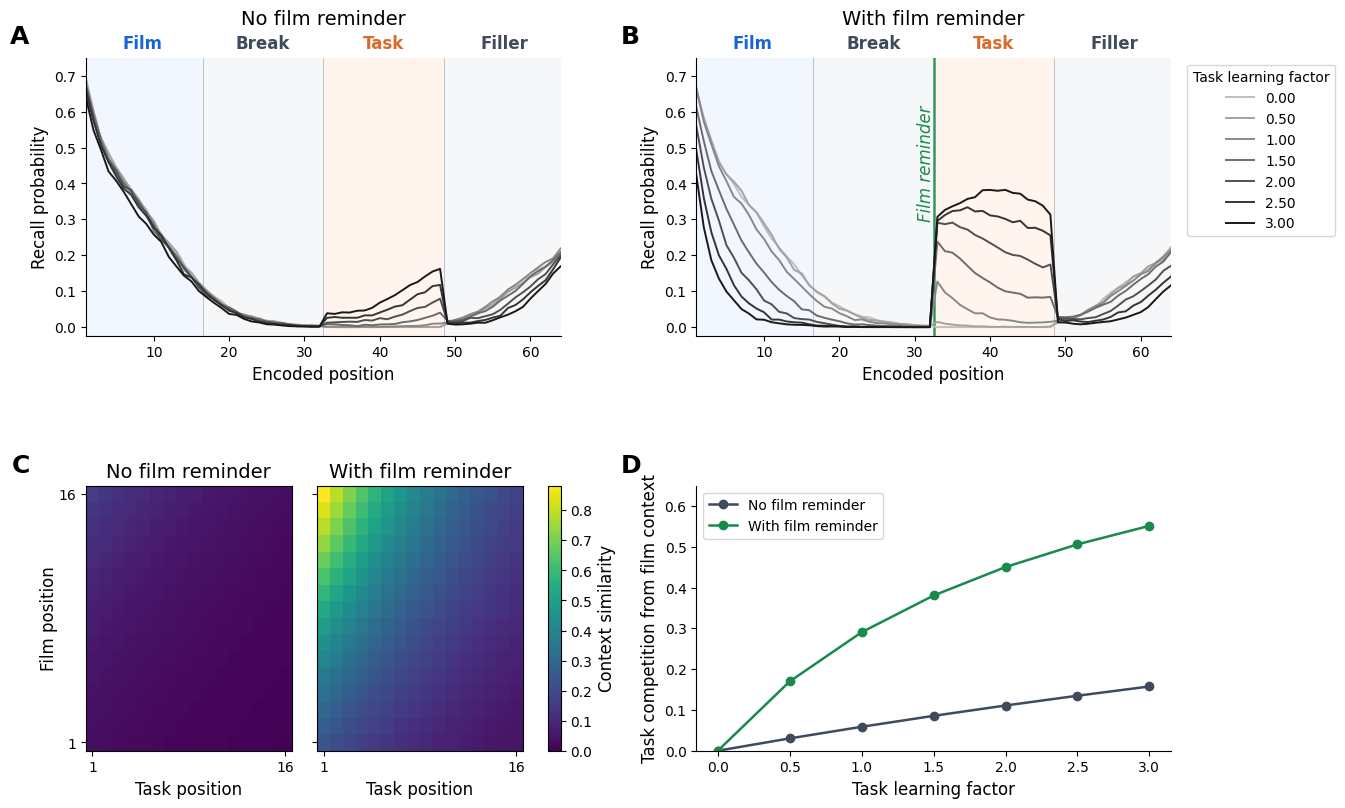

In [10]:
PANEL_LETTER_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 14
STRUCTURAL_FONTSIZE = 12
SUPPORT_FONTSIZE = 10


CONDITION_LABELS = {
    "No reminder": "No film reminder",
    "With reminder": "With film reminder",
}


def add_panel_label(axis, label, x=-0.16):
    axis.text(
        x,
        1.12,
        label,
        transform=axis.transAxes,
        fontsize=PANEL_LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


def add_phase_boundaries(axis):
    boundaries = np.cumsum([
        paradigm.n_film,
        paradigm.n_break,
        paradigm.n_interference,
    ]) + 0.5
    for boundary in boundaries:
        axis.axvline(boundary, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)


def add_reminder_marker(axis):
    reminder_x = paradigm.n_film + paradigm.n_break + 0.5
    axis.axvline(
        reminder_x,
        color=PHASE_COLORS["reminder"],
        linewidth=1.8,
        alpha=0.85,
        zorder=2,
    )
    axis.text(
        reminder_x - 1.05,
        0.62,
        "Film reminder",
        ha="center",
        va="center",
        fontsize=STRUCTURAL_FONTSIZE,
        fontstyle="italic",
        color=PHASE_COLORS["reminder"],
        rotation=90,
        rotation_mode="anchor",
        transform=axis.get_xaxis_transform(),
        clip_on=False,
        zorder=3,
    )


def plot_spc_panel(axis, condition, label, show_reminder=False):
    add_phase_bands(axis, position_phase, fontsize=STRUCTURAL_FONTSIZE)
    add_phase_boundaries(axis)
    if show_reminder:
        add_reminder_marker(axis)
    colors = light_to_dark_colors(len(sweep_values))
    positions = np.arange(1, n_presented + 1)
    for color, value, curve in zip(colors, sweep_values, spc_curves[condition]):
        axis.plot(
            positions,
            curve,
            color=color,
            linewidth=1.4,
            label=SWEEP_LABEL_FMT.format(value),
        )
    axis.set_title(CONDITION_LABELS[condition], fontsize=PANEL_TITLE_FONTSIZE, pad=24)
    axis.set_xlabel("Encoded position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(1, n_presented)
    axis.set_ylim(-0.025, 0.75)
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    add_panel_label(axis, label)


fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    2,
    4,
    height_ratios=[1.05, 1.0],
    hspace=0.55,
    wspace=0.80,
)

axis_a = fig.add_subplot(gs[0, 0:2])
axis_b = fig.add_subplot(gs[0, 2:4], sharey=axis_a)
plot_spc_panel(axis_a, "No reminder", "A")
plot_spc_panel(axis_b, "With reminder", "B", show_reminder=True)
axis_a.set_ylabel("Recall probability", fontsize=STRUCTURAL_FONTSIZE)
axis_b.set_ylabel("Recall probability", fontsize=STRUCTURAL_FONTSIZE)
axis_b.tick_params(labelleft=True)
axis_b.legend(
    title=SWEEP_XLABEL,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=SUPPORT_FONTSIZE,
    title_fontsize=SUPPORT_FONTSIZE,
)

c_gs = gs[1, 0:2].subgridspec(1, 3, width_ratios=[1, 1, 0.06], wspace=0.18)
axis_c1 = fig.add_subplot(c_gs[0, 0])
axis_c2 = fig.add_subplot(c_gs[0, 1], sharex=axis_c1, sharey=axis_c1)
axis_cbar = fig.add_subplot(c_gs[0, 2])
heat_vmax = max(float(np.max(value)) for value in context_similarity.values())
heat_vmin = min(0.0, min(float(np.min(value)) for value in context_similarity.values()))
heat_axes = [(axis_c1, "No reminder"), (axis_c2, "With reminder")]
image = None
for axis, condition in heat_axes:
    image = axis.imshow(
        context_similarity[condition],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=heat_vmin,
        vmax=heat_vmax,
    )
    axis.set_title(CONDITION_LABELS[condition], fontsize=PANEL_TITLE_FONTSIZE)
    axis.set_xlabel("Task position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xticks([0, paradigm.n_interference - 1])
    axis.set_xticklabels([1, paradigm.n_interference])
    axis.set_yticks([0, paradigm.n_film - 1])
    axis.set_yticklabels([1, paradigm.n_film])
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
axis_c1.set_ylabel("Film position", labelpad=0, fontsize=STRUCTURAL_FONTSIZE)
axis_c2.tick_params(labelleft=False)
colorbar = fig.colorbar(image, cax=axis_cbar)
colorbar.set_label("Context similarity", fontsize=STRUCTURAL_FONTSIZE)
colorbar.ax.tick_params(labelsize=SUPPORT_FONTSIZE)
add_panel_label(axis_c1, "C", x=-0.36)

axis_d = fig.add_subplot(gs[1, 2:4])
axis_d.plot(
    sweep_values,
    support_share["No reminder"],
    marker="o",
    color="#3D4B5C",
    label="No film reminder",
    linewidth=1.8,
)
axis_d.plot(
    sweep_values,
    support_share["With reminder"],
    marker="o",
    color=PHASE_COLORS["reminder"],
    label="With film reminder",
    linewidth=1.8,
)
axis_d.set_xlabel(SWEEP_XLABEL, fontsize=STRUCTURAL_FONTSIZE)
axis_d.set_ylabel("Task competition from film context", fontsize=STRUCTURAL_FONTSIZE)
axis_d.set_ylim(0, 0.65)
axis_d.tick_params(labelsize=SUPPORT_FONTSIZE)
axis_d.spines["top"].set_visible(False)
axis_d.spines["right"].set_visible(False)
axis_d.legend(loc="upper left", fontsize=SUPPORT_FONTSIZE)
add_panel_label(axis_d, "D")

save_figure(str(figure_dir) if figure_dir is not None else "", FIGURE_STR)

In [11]:
for condition in REMINDER_CONDITIONS:
    low = 0
    high = -1
    film_positions = [i for i, phase in enumerate(position_phase) if phase == "film"]
    task_positions = [i for i, phase in enumerate(position_phase) if phase == "task"]
    low_film = float(np.sum(spc_curves[condition][low][film_positions]))
    high_film = float(np.sum(spc_curves[condition][high][film_positions]))
    low_task = float(np.sum(spc_curves[condition][low][task_positions]))
    high_task = float(np.sum(spc_curves[condition][high][task_positions]))
    mean_similarity = float(np.mean(context_similarity[condition]))
    low_share = float(support_share[condition][low])
    high_share = float(support_share[condition][high])
    print(condition)
    print(f"  Film recall probability mass: {low_film:.2f} -> {high_film:.2f}")
    print(f"  Task recall probability mass: {low_task:.2f} -> {high_task:.2f}")
    print(f"  Mean film-task context similarity: {mean_similarity:.3f}")
    print(f"  Task share of film-cue support: {low_share:.3f} -> {high_share:.3f}")

No reminder
  Film recall probability mass: 5.63 -> 5.07
  Task recall probability mass: 0.00 -> 1.34
  Mean film-task context similarity: 0.041
  Task share of film-cue support: 0.000 -> 0.158
With reminder
  Film recall probability mass: 5.44 -> 1.38
  Task recall probability mass: 0.00 -> 5.66
  Mean film-task context similarity: 0.267
  Task share of film-cue support: 0.000 -> 0.551
